# Demand-Side Management MPC (DSMPC) Simulations HALL AND ERDIN

Copyright &copy; 2024, Alexander Erdin (aerdin@ethz.ch), ETH Zurich

This project is licensed under the MIT License.

## Setup

In [1]:
# Reload scripts when executed
%load_ext autoreload
%autoreload 2

In [2]:
import warnings
import casadi
import cvxpy as cp
import numpy as np
import pandas as pd
from time import sleep
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
from matplotlib.colors import LightSource
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection
from matplotlib import colormaps
from params import DSMPCParams
from systems import LinearSystem
from controllers import EMPC, CEMPC
from IPython.display import clear_output
from utils import adjust_margins

In [3]:
# Fix random seed and print options
np.random.seed(1)
np.set_printoptions(threshold=10000, linewidth=np.inf)

## Generate Time-Varying Parameters

In [4]:
# Define period length and number of agents
T, M = 96, 10

# Define time-varying leakage rate and the charging efficiency
alpha = 5*(.5 - np.random.rand(T, M))
beta  = 5*(.5 - np.random.rand(T, M))

# Load parameters and create system
zeta_max = 10 * np.ones([T,10]); zeta_max[23::24,:] = 1; zeta_max[42] = 15
params = DSMPCParams(T=T, M=M, zeta_max=zeta_max, zeta_min=-zeta_max, alpha=alpha, beta=beta)
sys = LinearSystem(params.sys)

# Define function to generate random disturbances within box constraint
def add_boxed_noise(x0, lb, ub, noise_level=0.5):
    # Reshape inputs
    x0 = x0.reshape(-1)
    lb = lb.reshape(-1)
    ub = ub.reshape(-1)

    # Compute standard deviation for each dimension
    stdev = noise_level * np.minimum(x0-lb, ub-x0)

    # Return truncated gaussian noise
    return x0 + np.clip(stdev * np.random.standard_normal(size=x0.shape), lb-x0, ub-x0)

## Approximate Infinite-Horizon Overtaking-Optimal Trajectory

In [5]:
# Define number of periods
N = 6

# Load parameters and create system with a long horizon
params_inf = DSMPCParams(N=N*T, T=T, M=M, zeta_max=zeta_max, zeta_min=-zeta_max, alpha=np.tile(alpha, (N,1)), beta=np.tile(beta, (N,1)))
sys_inf = LinearSystem(params_inf.sys)

# Initialize controller
ctrl_inf = EMPC(sys_inf, params_inf.ctrl, solver='cvxpy')

# Solve EMPC problem with free initial state
sol_u, sol_x, error_msg, dual_vars_inf, _ = ctrl_inf.solve(t=0)
if error_msg != None:
    warnings.warn(error_msg)

# Save trajectory
x_inf = sol_x.T
u_inf = sol_u.T

### Plot Trajectory

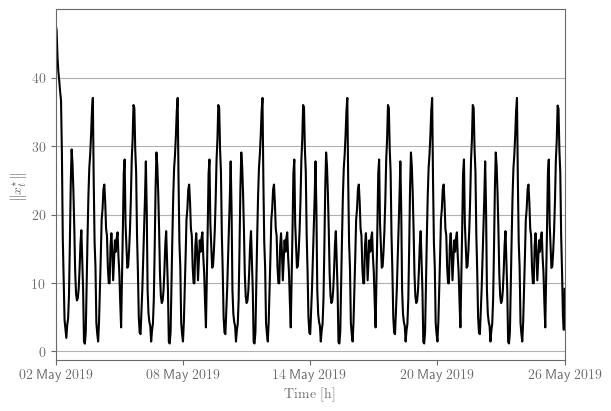

In [6]:
# Set rcParams
export = False
plt.style.use('default') # 'seaborn-v0_8-darkgrid
plt.rcParams['text.usetex'] = True
plt.rcParams['xtick.color'] = 'dimgray'
plt.rcParams['ytick.color'] = 'dimgray'
plt.rcParams['axes.edgecolor'] = 'dimgray'
plt.rcParams['axes.labelcolor'] = 'dimgray'
plt.rcParams['lines.linewidth'] = 1.5

# Create dates and norm vector
dates = np.hstack([params_inf.ctrl.start_date + pd.Timedelta(hours = h) for h in range(N*T+1)])

# Compute L2-norm
norm_x_inf = np.linalg.norm(x_inf, axis=1)

# Create figure
fig, ax = plt.subplots(1, 1, figsize=(6, 4), layout='constrained')

# Plot trajectory
ax.plot(dates, norm_x_inf, color='black')

# Add labels and title
ax.set_xlabel(r'\rmfamily{Time [h]}')
ax.set_ylabel(r'$\bigl\|x_t^\star\bigr\|$')

# Set major and minor ticks
plt.rcParams['timezone'] = dates[0].tz.zone
ax.xaxis.set_major_locator(mdates.DayLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter(r'%d %b %Y'))
ax.yaxis.set_major_locator(ticker.MultipleLocator(base=10, offset=0))
# ax.tick_params(axis="x", which="minor", pad=ax.xaxis.get_tick_padding())

# Set limits
ax.set_xlim([dates[0], dates[-1]])

# Set grid
ax.yaxis.grid(True)
ax.xaxis.grid(False)

# Export figure
if export:
    fig = adjust_margins(fig, width=4, height=2.5, wspace=1.1)
    fig.savefig(f"figures/figure_approximate_infinite_horizon_trajectory_sim.pdf")

## Simulate System Without Terminal Ingredients

### Solve DSMPC for Varying Initial States

In [ ]:
# Initialize controller
params.ctrl.N = 24
ctrl = EMPC(sys, params.ctrl)

# Setup simulation
num_steps = 48
x_0 = [np.tile(np.array([10/4*i, 15/4*i]), 10) for i in range(5)]
num_traj  = len(x_0)

# Allocate state and input trajectories
x = np.full((num_traj, num_steps+1, sys.n), np.nan)
u = np.full((num_traj, num_steps,   sys.m), np.nan)
x_ol = np.full((num_traj, params.ctrl.N+1, sys.n), np.nan)
u_ol = np.full((num_traj, params.ctrl.N,   sys.m), np.nan)

# Simulate closed-loop system
for i, xi_0 in enumerate(tqdm(x_0, desc='Trajectories', leave=False)):
    # Set initial state
    x[i,0,:] = xi_0

    # Simulate closed-loop system
    for t in tqdm(range(num_steps),desc='     MPC', leave=False):
        # Solve the EMPC problem
        sol_u, sol_x, error_msg, _, _ = ctrl.solve(t=t, x_0=x[i,t,:])
        if error_msg != None:
            print(f"Trajectory {i} at time {t} failed to solve the EMPC problem.")
            warnings.warn(error_msg)
            break

        # Save open-loop trajectory
        if t == 0:
            x_ol[i,:] = sol_x.T
            u_ol[i,:] = sol_u.T

        # Propagate dynamics and save input
        u[i,t,:]   = sol_u[:,0]
        x[i,t+1,:] = sys.f(sol_x[:,0], sol_u[:,0], t=t).reshape((sys.n,))

        # Add (bounded) disturbance
        lb = np.vstack([params.ctrl.zeta_min[t+1,:], np.zeros(params.M)]).T.reshape(-1,1)
        ub = np.vstack([params.ctrl.zeta_max[t+1,:], params.ctrl.q_max[t,:]]).T.reshape(-1,1)
        x[i,t+1,:] = add_boxed_noise(x[i,t+1,:], lb, ub, noise_level=0.1)
        sleep(0.01)

# Clear cell output
clear_output()

### Solve DSMPC for Varying Horizons

In [ ]:
# Setup simulation
num_steps = 48
horizon = [6, 9, 12, 18, 24, 36, 48]
num_horizon = len(horizon)

# Allocate state and input trajectories
x2 = np.full((num_horizon, num_steps+1, sys.n), np.nan)
u2 = np.full((num_horizon, num_steps,   sys.m), np.nan)
x2_ol = np.full((num_horizon, num_steps, max(horizon)+1, sys.n), np.nan)
u2_ol = np.full((num_horizon, num_steps, max(horizon),   sys.m), np.nan)

# Simulate closed-loop system
for i, N in enumerate(tqdm(horizon, desc='Horizons', leave=False)):
    # Initialize controller
    params.ctrl.N = N
    ctrl2 = EMPC(sys, params.ctrl)

    # Set initial state
    x2[i,0,:] = np.tile(np.array([7.5, 11.2]), 10)

    # Simulate closed-loop system
    for t in tqdm(range(num_steps),desc='   MPC', leave=False):
        # Solve the EMPC problem
        sol_u, sol_x, error_msg, _, _ = ctrl2.solve(t=t, x_0=x2[i,t,:])
        if error_msg != None:
            warnings.warn(error_msg)
            break
        
        # Save open-loop trajectory
        x2_ol[i,t,:N+1,:] = sol_x.T
        u2_ol[i,t,:N,:]   = sol_u.T

        # Propagate dynamics and save input
        u2[i,t,:]   = sol_u[:,0]
        x2[i,t+1,:] = sys.f(sol_x[:,0], sol_u[:,0], t=t).reshape((sys.n,))

        # Add (bounded) disturbance
        lb = np.vstack([params.ctrl.zeta_min[t+1,:], np.zeros(params.M)]).T.reshape(-1,1)
        ub = np.vstack([params.ctrl.zeta_max[t+1,:], params.ctrl.q_max[t,:]]).T.reshape(-1,1)
        x[i,t+1,:] = add_boxed_noise(x[i,t+1,:], lb, ub, noise_level=0.1)
        sleep(0.01)

# Clear cell output
clear_output()

### Convergence to the Overtaking-Optimal Trajectory

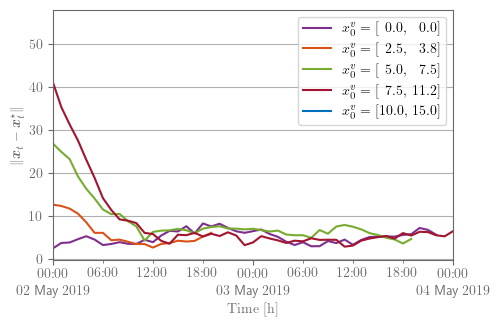

In [18]:
# Set rcParams
export = True
plt.style.use('default') # 'seaborn-v0_8-darkgrid
plt.rcParams['text.usetex'] = True
plt.rcParams['xtick.color'] = 'dimgray'
plt.rcParams['ytick.color'] = 'dimgray'
plt.rcParams['axes.edgecolor'] = 'dimgray'
plt.rcParams['axes.labelcolor'] = 'dimgray'
plt.rcParams['lines.linewidth'] = 1.5
plt.rcParams['text.latex.preamble'] = r"""\usepackage{bm}"""

# Create time vector
dates = [params.ctrl.start_date + pd.Timedelta(hours = h) for h in range(num_steps+1)]

# Compute L2-norm
diff_x = np.full((num_traj, num_steps+1), np.nan)
for i in range(num_traj):
    diff_x[i,:] = np.linalg.norm(x[i,:,:] - x_inf[2*T:2*T+num_steps+1,:], axis=1)

# Create colormap
colors = lambda i: ["#0072BD", "#A2142F", "#77AC30", "#D95319", "#7E2F8E", "#4DBEEE", "#EDB120"][i % 7]

# Create figure
fig, axs = plt.subplots(1, 1, figsize=(12, 4), layout='constrained')

# Plot trajectories without terminal constraints
for i in range(num_traj):
    label_name = np.array2string(x_0[i][0:2], separator=',\,', formatter={'float_kind':lambda x: f"{x:4.1f}".replace(' ', r'\phantom{0}')})
    axs.plot(dates, diff_x[i,:], color=colors(num_traj-i-1), linestyle='-', label=f'$x_0^v = {label_name}$')

# Add labels
axs.set_ylabel(r"$\|\bm{x}_t - \bm{x}_t^\star\|$")
axs.set_xlabel(r'\rmfamily{Time [h]}')

# Set major and minor ticks
plt.rcParams['timezone'] = dates[0].tz.zone
axs.xaxis.set_major_locator(mdates.DayLocator(interval=1))
axs.xaxis.set_minor_locator(mdates.HourLocator(byhour=[6,12,18]))
axs.xaxis.set_major_formatter(mdates.DateFormatter(r'%H:%M\\%d %b %Y'))
axs.xaxis.set_minor_formatter(mdates.DateFormatter(r'%H:%M'))

# Set axis limits
axs.set_xlim([dates[0], dates[-1]])

# Set grid
axs.yaxis.grid(True)
axs.xaxis.grid(False)
# axs.set_yscale('log')

# Align labels
fig.align_labels()

# Plot legend
axs.legend(loc='best')

# Export figure
if export:
    fig = adjust_margins(fig, width=4, height=2.5, wspace=1.1)
    fig.savefig(f"figures/figure_asymptotic_convergence_L2norm.pdf")

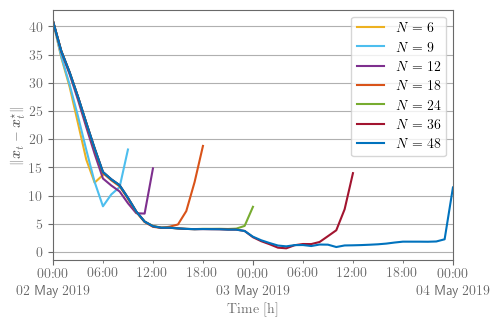

In [137]:
# Set rcParams
export = True
plt.style.use('default') # 'seaborn-v0_8-darkgrid
plt.rcParams['text.usetex'] = True
plt.rcParams['xtick.color'] = 'dimgray'
plt.rcParams['ytick.color'] = 'dimgray'
plt.rcParams['axes.edgecolor'] = 'dimgray'
plt.rcParams['axes.labelcolor'] = 'dimgray'
plt.rcParams['lines.linewidth'] = 1.5
plt.rcParams['text.latex.preamble'] = r"""\usepackage{bm}"""

# Create time vector
dates = [params.ctrl.start_date + pd.Timedelta(hours = h) for h in range(num_steps+max(horizon)+1)]

# Compute L2-norm
diff_x2_ol = np.full((num_horizon, num_steps, num_steps+max(horizon)+1), np.nan)
for i in range(num_horizon):
    for t in range(num_steps):
        diff_x2_ol[i,t,t:t+horizon[i]+1] = np.linalg.norm(x2_ol[i,t,:horizon[i]+1,:] - x_inf[t+2*T:t+2*T+horizon[i]+1,:], axis=1)  

# Create colormap
colors = lambda i: ["#0072BD", "#A2142F", "#77AC30", "#D95319", "#7E2F8E", "#4DBEEE", "#EDB120"][i % 7]

# Create figure
t = 0
fig, axs = plt.subplots(1, 1, figsize=(12, 4), layout='constrained')

# Plot trajectories without terminal constraints
for i in range(num_horizon):
    axs.plot(dates, diff_x2_ol[i,t,:], color=colors(num_horizon-i-1), linestyle='-', label=f'$N = {horizon[i]}$')

# Add labels
axs.set_ylabel(r"$\|\bm{x}_t - \bm{x}_t^\star\|$")
axs.set_xlabel(r'\rmfamily{Time [h]}')

# Set major and minor ticks
plt.rcParams['timezone'] = dates[0].tz.zone
axs.xaxis.set_major_locator(mdates.DayLocator(interval=1))
axs.xaxis.set_minor_locator(mdates.HourLocator(byhour=[6,12,18]))
axs.xaxis.set_major_formatter(mdates.DateFormatter(r'%H:%M\\%d %b %Y'))
axs.xaxis.set_minor_formatter(mdates.DateFormatter(r'%H:%M'))

# Set axis limits
axs.set_xlim([dates[0], dates[max(horizon)]])

# Set grid
axs.yaxis.grid(True)
axs.xaxis.grid(False)
# axs.set_yscale('log')

# Align labels
fig.align_labels()

# Plot legend
axs.legend(loc='best')

# Export figure
if export:
    fig = adjust_margins(fig, width=4, height=2.5, wspace=1.1)
    fig.savefig(f"figures/figure_turnpike_L2norm_t0_{t:0.1f}.pdf")

## Simulate System With Terminal Ingredients

### Compute Periodic Reference Trajectory

In [19]:
# Initialize controller
params.ctrl.N = T
ctrl_p = CEMPC(sys, params.ctrl)

# Solve EMPC problem with free initial state
sol_u, sol_x, error_msg, dual_vars_p, stats = ctrl_p.solve(options={'eps_rel': 1E-10, 'eps_abs': 1E-10})
if error_msg != None:
    warnings.warn(error_msg)

# Save trajectory
x_p = sol_x.T
u_p = sol_u.T

Convexification problem solved with minimal eigenvalue: 0.09995340898761196
LMIs is positive definite for all times.


### Solve DSMPC for Varying Initial States

In [21]:
# Initialize controller
params_p = ctrl_p.params
params_p.N = 24
ctrl = EMPC(sys, params_p)

# Setup simulation
num_steps = 48
xt_0 = [np.tile(np.array([10/4*i, 15/4*i]), 10) for i in range(5)]
num_traj  = len(x_0)

# Allocate state and input trajectories
xt = np.full((num_traj, num_steps+1, sys.n), np.nan)
ut = np.full((num_traj, num_steps,   sys.m), np.nan)
xt_ol = np.full((num_traj, params_p.N+1, sys.n), np.nan)
ut_ol = np.full((num_traj, params_p.N,   sys.m), np.nan)

# Simulate closed-loop system
for i, xi_0 in enumerate(tqdm(xt_0, desc='Trajectories', leave=False)):
    # Set initial state
    xt[i,0,:] = xi_0

    # Simulate closed-loop system
    for t in tqdm(range(num_steps),desc='     MPC', leave=False):
        # Solve the EMPC problem
        sol_u, sol_x, error_msg, _, _ = ctrl.solve(t=t, x_0=xt[i,t,:], x_T=x_p[t+params_p.N,:])
        if error_msg != None:
            warnings.warn(error_msg)
            break
        
        # Save open-loop trajectory
        if t == 0:
            xt_ol[i,:] = sol_x.T
            ut_ol[i,:] = sol_u.T

        # Propagate dynamics and save input
        ut[i,t,:]   = sol_u[:,0]
        xt[i,t+1,:] = sys.f(sol_x[:,0], sol_u[:,0], t=t).reshape((sys.n,))

        # Add (bounded) disturbance
        lb = np.vstack([params.ctrl.zeta_min[t+1,:], np.zeros(params.M)]).T.reshape(-1,1)
        ub = np.vstack([params.ctrl.zeta_max[t+1,:], params.ctrl.q_max[t,:]]).T.reshape(-1,1)
        xt[i,t+1,:] = add_boxed_noise(xt[i,t+1,:], lb, ub, noise_level=0.1)
        sleep(0.01)

# Clear cell output
clear_output()

### Solve DSMPC for Varying Horizons

In [30]:
# Setup simulation
num_steps = 48
horizont = [24, 36, 48]
num_horizont = len(horizont)

# Allocate state and input trajectories
xt2 = np.full((num_horizont, num_steps+1, sys.n), np.nan)
ut2 = np.full((num_horizont, num_steps,   sys.m), np.nan)
xt2_ol = np.full((num_horizont, num_steps, max(horizont)+1, sys.n), np.nan)
ut2_ol = np.full((num_horizont, num_steps, max(horizont),   sys.m), np.nan)

# Simulate closed-loop system
for i, N in enumerate(tqdm(horizont, desc='Horizons', leave=False)):
    # Load parameters and create system
    params_p.N = N

    # Initialize controller
    ctrl2 = EMPC(sys, params_p)

    # Set initial state
    xt2[i,0,:] = np.tile(np.array([10, 15]), 10)

    # Simulate closed-loop system
    for t in tqdm(range(num_steps),desc='   MPC', leave=False):
        # Solve the EMPC problem
        sol_u, sol_x, error_msg, _, _ = ctrl2.solve(t=t, x_0=xt2[i,t,:], x_T=x_p[t+N,:])
        if error_msg != None:
            warnings.warn(error_msg)
            break
        
        # Save open-loop trajectory
        xt2_ol[i,t,:N+1,:] = sol_x.T
        ut2_ol[i,t,:N,:]   = sol_u.T

        # Propagate dynamics and save input
        ut2[i,t,:]   = sol_u[:,0]
        xt2[i,t+1,:] = sys.f(sol_x[:,0], sol_u[:,0], t=t).reshape((sys.n,))

        # Add (bounded) disturbance
        lb = np.vstack([params.ctrl.zeta_min[t+1,:], np.zeros(params.M)]).T.reshape(-1,1)
        ub = np.vstack([params.ctrl.zeta_max[t+1,:], params.ctrl.q_max[t,:]]).T.reshape(-1,1)
        xt2[i,t+1,:] = add_boxed_noise(xt2[i,t+1,:], lb, ub, noise_level=0.1)
        sleep(0.01)

# Clear cell output
clear_output()

### Compare Cost

In [ ]:
# Compute cost with and without terminal constraints
data = []
for i in range(num_traj):
    cost, costt = 0, 0
    for k in range(num_steps):
        cost  += params.ctrl.stage_cost(x[i, k],  u[i, k],  t=k)[0]
        costt += params.ctrl.stage_cost(xt[i, k], ut[i, k], t=k)[0]
    
    # Append the computed costs
    data.append([cost, costt, np.abs(cost/costt-1)])

# Create a pandas DataFrame
columns = pd.MultiIndex.from_tuples([('Cost', 'Without'), ('Cost', 'With'), ('Rel. Diff','[%]')])
cost_df = pd.DataFrame(data, columns=columns, index=pd.Index(range(num_traj), name="Trajectory"))
cost_df